# Qwen2.5-VL Multi-Image Fine-Tuning for Litter Detection

This notebook fine-tunes `Qwen/Qwen2.5-VL-3B-Instruct` on the JSONL dataset where each sample contains one context image plus one or more crop images.

Expected JSONL shape per row:
- `images`: list of objects with `uri` and `role`
- `instruction`: user instruction
- `output`: target JSON object


## 1. Install Dependencies

Run this cell once in a fresh environment. If you already have matching versions installed, you can skip it.

In [1]:
%pip install -U transformers trl datasets peft bitsandbytes accelerate pillow tensorboard sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 166.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 187.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 196.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 59.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
     

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [2]:
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/Qwen updated")
TRAIN_FILE = DATA_ROOT / "train.jsonl"
VAL_FILE = DATA_ROOT / "val.jsonl"
TEST_FILE = DATA_ROOT / "test.jsonl"

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
OUTPUT_DIR = Path("./outputs/qwen25vl-litter-multiimage")

MAX_TRAIN_SAMPLES = None  # set to a small int like 100 for a quick smoke test
MAX_EVAL_SAMPLES = None
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 4
LEARNING_RATE = 1e-4
LOGGING_STEPS = 5
SAVE_STEPS = 100
EVAL_STEPS = 100
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
MAX_CROPS_PER_SAMPLE = None  # this is set to 4, 8, etc. if multi-image samples cause OOM
SEED = 42

assert TRAIN_FILE.exists(), f"Missing {TRAIN_FILE}"
assert VAL_FILE.exists(), f"Missing {VAL_FILE}"
assert TEST_FILE.exists(), f"Missing {TEST_FILE}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data root:", DATA_ROOT)
print("Output dir:", OUTPUT_DIR.resolve())

Data root: /content/drive/MyDrive/Qwen updated
Output dir: /content/outputs/qwen25vl-litter-multiimage


## 3. Imports and Environment Checks

In [3]:
import io
import json
import random
from pathlib import Path

import torch
from PIL import Image
from datasets import DatasetDict, load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen2_5_VLForConditionalGeneration,
    set_seed,
)
from trl import SFTConfig, SFTTrainer

set_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for QLoRA fine-tuning of Qwen2.5-VL.")

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print("CUDA:", torch.cuda.get_device_name(0))
print("Compute dtype:", DTYPE)

try:
    import flash_attn  # noqa: F401
    ATTN_IMPL = "flash_attention_2"
except Exception:
    ATTN_IMPL = "sdpa"

print("Attention implementation:", ATTN_IMPL)

CUDA: NVIDIA RTX PRO 6000 Blackwell Server Edition
Compute dtype: torch.bfloat16
Attention implementation: sdpa


## 4. Load the JSONL Dataset

In [4]:
raw_ds = load_dataset(
    "json",
    data_files={
        "train": str(TRAIN_FILE),
        "validation": str(VAL_FILE),
        "test": str(TEST_FILE),
    },
)

if MAX_TRAIN_SAMPLES is not None:
    raw_ds["train"] = raw_ds["train"].select(range(min(MAX_TRAIN_SAMPLES, len(raw_ds["train"]))))
if MAX_EVAL_SAMPLES is not None:
    raw_ds["validation"] = raw_ds["validation"].select(range(min(MAX_EVAL_SAMPLES, len(raw_ds["validation"]))))

raw_ds

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['images', 'instruction', 'output'],
        num_rows: 774
    })
    validation: Dataset({
        features: ['images', 'instruction', 'output'],
        num_rows: 97
    })
    test: Dataset({
        features: ['images', 'instruction', 'output'],
        num_rows: 97
    })
})

In [5]:
sample = raw_ds["train"][0]
print(json.dumps(sample, indent=2))

{
  "images": [
    {
      "uri": "full_images/Hygiene_105.jpg",
      "role": "context"
    },
    {
      "uri": "processed_full/crops/hygiene_Hygiene_105_00.jpg",
      "role": "crop"
    }
  ],
  "instruction": "Analyze the scene image together with the crop images.\n\nReturn ONLY JSON using this exact format:\n\n{\n \"counts\":{\n   \"food_drink\":int,\n   \"smoking\":int,\n   \"hygiene\":int,\n   \"waste\":int,\n   \"animal\":int,\n   \"hazard\":int\n },\n \"visual_density\":\"low|medium|high\",\n \"spatial_distribution\":\"clustered|scattered\",\n \"perception_score\":1-5,\n \"confidence\":0-1\n}",
  "output": {
    "counts": {
      "food_drink": 0,
      "smoking": 0,
      "hygiene": 1,
      "waste": 0,
      "animal": 0,
      "hazard": 0
    },
    "visual_density": "low",
    "spatial_distribution": "scattered",
    "perception_score": 1,
    "confidence": 0.9
  }
}


## 5. Format Each Row as a Multi-Image Chat Example

We keep image paths in the dataset and load PIL images inside the collator. This is lighter than storing image bytes in the Arrow dataset.

In [6]:
SYSTEM_PROMPT = (
    "You are a careful litter analysis assistant. Use the context image and all crop images together. "
    "Return only valid JSON that exactly follows the requested schema."
)

def resolve_image_path(uri: str) -> str:
    path = DATA_ROOT / uri
    if not path.exists():
        raise FileNotFoundError(f"Missing image: {path}")
    return str(path)

def build_user_content(images, instruction):
    content = [
        {"type": "text", "text": instruction.strip()},
        {"type": "text", "text": "Context image:"},
    ]

    context_images = [img for img in images if img.get("role") == "context"]
    crop_images = [img for img in images if img.get("role") == "crop"]

    for item in context_images:
        content.append({"type": "image"})

    for idx, _ in enumerate(crop_images, start=1):
        content.append({"type": "text", "text": f"Crop image {idx}:"})
        content.append({"type": "image"})

    return content

def format_example(example):
    context_images = [img for img in example["images"] if img.get("role") == "context"]
    crop_images = [img for img in example["images"] if img.get("role") != "context"]
    if MAX_CROPS_PER_SAMPLE is not None:
        crop_images = crop_images[:MAX_CROPS_PER_SAMPLE]
    ordered_images = context_images + crop_images
    image_paths = [resolve_image_path(img["uri"]) for img in ordered_images]
    assistant_text = json.dumps(example["output"], ensure_ascii=True, separators=(",", ":"))

    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": build_user_content(ordered_images, example["instruction"]),
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": assistant_text}],
        },
    ]

    return {
        "messages": messages,
        "image_paths": image_paths,
        "target_text": assistant_text,
        "num_images": len(image_paths),
    }

formatted_ds = DatasetDict({
    split: raw_ds[split].map(format_example, remove_columns=raw_ds[split].column_names)
    for split in raw_ds.keys()
})

formatted_ds

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/97 [00:00<?, ? examples/s]

Map:   0%|          | 0/97 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['messages', 'image_paths', 'target_text', 'num_images'],
        num_rows: 774
    })
    validation: Dataset({
        features: ['messages', 'image_paths', 'target_text', 'num_images'],
        num_rows: 97
    })
    test: Dataset({
        features: ['messages', 'image_paths', 'target_text', 'num_images'],
        num_rows: 97
    })
})

In [7]:
formatted_sample = formatted_ds["train"][0]
print("num_images:", formatted_sample["num_images"])
print("image_paths:")
for p in formatted_sample["image_paths"]:
    print(" -", p)

print("\nassistant target:")
print(formatted_sample["target_text"])

print("\nchat preview:")
print(json.dumps(formatted_sample["messages"], indent=2))

num_images: 2
image_paths:
 - /content/drive/MyDrive/Qwen updated/full_images/Hygiene_105.jpg
 - /content/drive/MyDrive/Qwen updated/processed_full/crops/hygiene_Hygiene_105_00.jpg

assistant target:
{"counts":{"food_drink":0,"smoking":0,"hygiene":1,"waste":0,"animal":0,"hazard":0},"visual_density":"low","spatial_distribution":"scattered","perception_score":1,"confidence":0.9}

chat preview:
[
  {
    "content": [
      {
        "type": "text",
        "text": "You are a careful litter analysis assistant. Use the context image and all crop images together. Return only valid JSON that exactly follows the requested schema."
      }
    ],
    "role": "system"
  },
  {
    "content": [
      {
        "type": "text",
        "text": "Analyze the scene image together with the crop images.\n\nReturn ONLY JSON using this exact format:\n\n{\n \"counts\":{\n   \"food_drink\":int,\n   \"smoking\":int,\n   \"hygiene\":int,\n   \"waste\":int,\n   \"animal\":int,\n   \"hazard\":int\n },\n \"visua

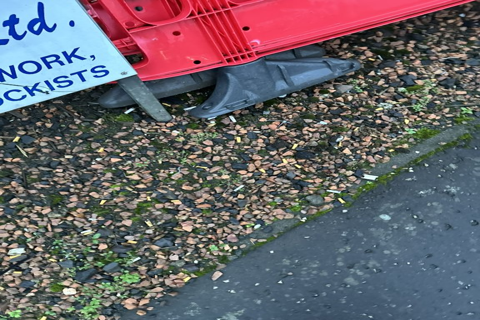

{"counts":{"food_drink":0,"smoking":9,"hygiene":0,"waste":0,"animal":0,"hazard":0},"visual_density":"high","spatial_distribution":"scattered","perception_score":4,"confidence":0.9}


In [8]:
preview_idx = random.randrange(len(formatted_ds["train"]))
preview = formatted_ds["train"][preview_idx]
display(Image.open(preview["image_paths"][0]).convert("RGB").resize((480, 320)))
print(preview["target_text"])

## 6. Load Processor and QLoRA Model

In [9]:
processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=True)
processor.tokenizer.padding_side = "right"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=DTYPE,
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map="auto",
    quantization_config=bnb_config,
    attn_implementation=ATTN_IMPL,
)

model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    target_modules="all-linear",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

trainable params: 41,363,456 || all params: 3,795,986,432 || trainable%: 1.0897


## 7. Collator for Multi-Image Supervised Fine-Tuning

Official TRL guidance for VLM training recommends `max_length=None` to avoid truncating image tokens. We also mask pad and image tokens in the labels.

In [10]:
def load_rgb(path: str) -> Image.Image:
    with Image.open(path) as img:
        return img.convert("RGB")

def find_image_token_ids(processor):
    token_ids = set()
    tokenizer = processor.tokenizer
    candidate_tokens = [
        "<|image_pad|>",
        "<|vision_start|>",
        "<|vision_end|>",
        "<|image_start|>",
        "<|image_end|>",
        "<image>",
    ]
    for token in candidate_tokens:
        token_id = tokenizer.convert_tokens_to_ids(token)
        if token_id is not None and token_id != tokenizer.unk_token_id:
            token_ids.add(token_id)
    return token_ids

IMAGE_TOKEN_IDS = find_image_token_ids(processor)
print("Image token ids to mask:", sorted(IMAGE_TOKEN_IDS))

def collate_fn(examples):
    texts = [
        processor.apply_chat_template(example["messages"], tokenize=False, add_generation_prompt=False)
        for example in examples
    ]
    images = [[load_rgb(path) for path in example["image_paths"]] for example in examples]

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt",
    )

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    for token_id in IMAGE_TOKEN_IDS:
        labels[labels == token_id] = -100

    batch["labels"] = labels
    return batch

batch_preview = collate_fn([formatted_ds["train"][0]])
{k: tuple(v.shape) for k, v in batch_preview.items() if hasattr(v, "shape")}

Image token ids to mask: [151652, 151653, 151655]


{'input_ids': (1, 776),
 'attention_mask': (1, 776),
 'mm_token_type_ids': (1, 776),
 'pixel_values': (2236, 1176),
 'image_grid_thw': (2, 3),
 'labels': (1, 776)}

## 8. Trainer Setup

In [11]:
training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    eval_steps=EVAL_STEPS,
    eval_strategy="steps",
    save_strategy="steps",
    bf16=(DTYPE == torch.bfloat16),
    fp16=(DTYPE == torch.float16),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    max_length=None,
    dataset_kwargs={"skip_prepare_dataset": True},
    remove_unused_columns=False,
    report_to="tensorboard",
    dataloader_num_workers=0,
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=formatted_ds["train"],
    eval_dataset=formatted_ds["validation"],
    data_collator=collate_fn,
    processing_class=processor,
)

trainer

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 9. Train

In [12]:
train_result = trainer.train()
train_result

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
100,0.019587,0.023047
200,0.015214,0.016898
300,0.011588,0.014547
400,0.006855,0.013209
500,0.007369,0.012694


The channel dimension is ambiguous. Got image shape torch.Size([3, 2, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 2, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 2, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


TrainOutput(global_step=582, training_loss=0.107421173787711, metrics={'train_runtime': 7761.1393, 'train_samples_per_second': 0.299, 'train_steps_per_second': 0.075, 'total_flos': 1.3646551252163789e+17, 'train_loss': 0.107421173787711})

In [13]:
trainer.save_model()
processor.save_pretrained(OUTPUT_DIR)
print("Saved adapter and processor to", OUTPUT_DIR.resolve())

Saved adapter and processor to /content/outputs/qwen25vl-litter-multiimage


## 10. Quick Validation Inference

This runs a generation pass on one validation sample using the currently loaded model.

In [37]:
model.eval()

val_example = formatted_ds["validation"][96]
prompt_messages = val_example["messages"][:-1]
prompt_text = processor.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
prompt_images = [load_rgb(path) for path in val_example["image_paths"]]

inputs = processor(text=[prompt_text], images=[prompt_images], return_tensors="pt", padding=True)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.no_grad():
    generated = model.generate(**inputs, max_new_tokens=256, do_sample=False)

generated_text = processor.batch_decode(generated, skip_special_tokens=True)[0]
print("MODEL OUTPUT:\n")
print(generated_text)

print("\nTARGET JSON:\n")
print(val_example["target_text"])

MODEL OUTPUT:

system
You are a careful litter analysis assistant. Use the context image and all crop images together. Return only valid JSON that exactly follows the requested schema.
user
Analyze the scene image together with the crop images.

Return ONLY JSON using this exact format:

{
 "counts":{
   "food_drink":int,
   "smoking":int,
   "hygiene":int,
   "waste":int,
   "animal":int,
   "hazard":int
 },
 "visual_density":"low|medium|high",
 "spatial_distribution":"clustered|scattered",
 "perception_score":1-5,
 "confidence":0-1
}Context image:Crop image 1:Crop image 2:
assistant
{"counts":{"food_drink":2,"smoking":0,"hygiene":0,"waste":0,"animal":0,"hazard":0},"visual_density":"low","spatial_distribution":"scattered","perception_score":2,"confidence":0.9}

TARGET JSON:

{"counts":{"food_drink":2,"smoking":0,"hygiene":0,"waste":0,"animal":0,"hazard":0},"visual_density":"low","spatial_distribution":"clustered","perception_score":2,"confidence":0.9}


Target JSON:
{"counts":{"food_drink":2,"smoking":0,"hygiene":0,"waste":0,"animal":0,"hazard":0},"visual_density":"low","spatial_distribution":"clustered","perception_score":2,"confidence":0.9}

Image paths:
0: /content/drive/MyDrive/Qwen updated/full_images/Mixed_Litter_041.JPG
1: /content/drive/MyDrive/Qwen updated/processed_full/crops/food_drinks_litter_Mixed_Litter_041_00.jpg
2: /content/drive/MyDrive/Qwen updated/processed_full/crops/food_drinks_litter_Mixed_Litter_041_01.jpg


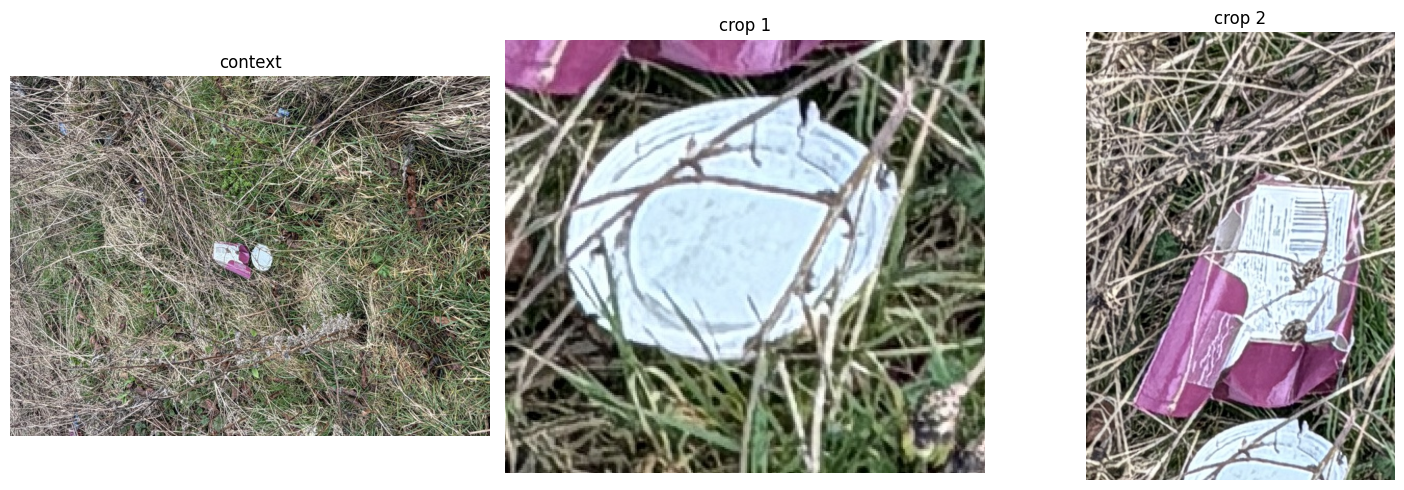

In [36]:
from PIL import Image
import matplotlib.pyplot as plt

idx = 96  # =the index
example = formatted_ds["validation"][idx]

print("Target JSON:")
print(example["target_text"])
print("\nImage paths:")
for i, p in enumerate(example["image_paths"]):
    print(f"{i}: {p}")

n = len(example["image_paths"])
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

if n == 1:
    axes = [axes]

for i, path in enumerate(example["image_paths"]):
    img = Image.open(path).convert("RGB")
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title("context" if i == 0 else f"crop {i}")

plt.tight_layout()
plt.show()


In [39]:
def predict_example(example):
    prompt_messages = example["messages"][:-1]
    prompt_text = processor.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    prompt_images = [load_rgb(path) for path in example["image_paths"]]

    inputs = processor(
        text=[prompt_text],
        images=[prompt_images],
        return_tensors="pt",
        padding=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
        )

    input_len = inputs["input_ids"].shape[1]
    generated_only = generated[:, input_len:]

    return processor.batch_decode(
        generated_only,
        skip_special_tokens=True
    )[0].strip()


In [40]:
example = formatted_ds["validation"][0]
pred_text = predict_example(example)
print(repr(pred_text))
print(example["target_text"])


'{"counts":{"food_drink":0,"smoking":0,"hygiene":6,"waste":0,"animal":0,"hazard":0},"visual_density":"high","spatial_distribution":"scattered","perception_score":3,"confidence":0.9}'
{"counts":{"food_drink":1,"smoking":0,"hygiene":5,"waste":0,"animal":0,"hazard":0},"visual_density":"high","spatial_distribution":"scattered","perception_score":3,"confidence":0.9}


In [43]:
import json
import torch
from tqdm.auto import tqdm

SPLIT = "test"
MAX_SAMPLES = None
COUNT_KEYS = ["food_drink", "smoking", "hygiene", "waste", "animal", "hazard"]

def dominant_litter_source(obj):
    counts = obj["counts"]
    max_value = max(counts[k] for k in COUNT_KEYS)
    winners = [k for k in COUNT_KEYS if counts[k] == max_value]
    if max_value == 0:
        return "none"
    if len(winners) > 1:
        return "tie"
    return winners[0]

def predict_example(example):
    prompt_messages = example["messages"][:-1]
    prompt_text = processor.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    prompt_images = [load_rgb(path) for path in example["image_paths"]]

    inputs = processor(
        text=[prompt_text],
        images=[prompt_images],
        return_tensors="pt",
        padding=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
        )

    input_len = inputs["input_ids"].shape[1]
    generated_only = generated[:, input_len:]

    return processor.batch_decode(
        generated_only,
        skip_special_tokens=True
    )[0].strip()

dataset = formatted_ds[SPLIT]
if MAX_SAMPLES is not None:
    dataset = dataset.select(range(min(MAX_SAMPLES, len(dataset))))

model.eval()

total = 0
valid_json = 0
correct = 0

for example in tqdm(dataset):
    pred_text = predict_example(example)
    true_obj = json.loads(example["target_text"])

    total += 1

    try:
        pred_obj = json.loads(pred_text)
        valid_json += 1

        pred_dom = dominant_litter_source(pred_obj)
        true_dom = dominant_litter_source(true_obj)

        if pred_dom == true_dom:
            correct += 1
    except Exception:
        pass

print(f"Samples: {total}")
print(f"Valid JSON rate: {valid_json / total:.4f}")
print(f"Dominant litter source accuracy: {correct / total:.4f}")


  0%|          | 0/97 [00:00<?, ?it/s]

Samples: 97
Valid JSON rate: 1.0000
Dominant litter source accuracy: 0.8454


## Notes

- Default base model is `Qwen/Qwen2.5-VL-3B-Instruct` because it is the easiest QLoRA starting point.